# Exercises: Calculating pressures, fluid compositions, and degassing paths

Ery C. Hughes <i> add others </i>

<i>This exercise has been written for the 'Modelling the Behaviour of Volatiles in Magmas' workshop associated with Goldschmidt 2026 (Montréal, Québec, Canada) on Sunday 12th July 2026: https://kaylai.github.io/GS2026-volatiles-workshop/</i>

In these exercises we will calculate pressures, fluid compositions, and degassing paths using a variety of available tools (e.g., Thermobar - Wieser et al. 2022; VESIcal - Iacovino et al. 2021; VolFe - Hughes et al. 2025; DiadFit - Wieser & DeVitre 2024; Sulfur_X - Ding et al. 2023) through the VICTOR platform (Lev et al. 2025). Other tools are available for these types of calculations (e.g., Solwcad - Papale et al. 2006; D-Compress - Burgisser et al. 2015; CHOSETTO - Moretti and Ottonello 2003, Moretti and Papale 2004; EVo - Liggins et al. 2020, 2022; MAGEC - Sun and Lee 2022, Sun and Yao 2024) but we have chosen options available entirely through VICTOR.

Throughout these exercises we will use the 2018 Lower East Rift Zone eruption of Kı̄lauea as an example, which has lots of melt and fluid inclusion (MI, FI) data available (e.g., Wieser et al., 2021; DeVitre & Wieser, 2024).

## 0 Introduction

### 0.1 Python set-up
If you are running this notebook through your computer, you will need to install the relevant packages once on your computer, if you haven't already (remove the # before 'pip' on each line for packages you don't already have). 

If you are running this on the VICTOR platform, all packages are already installed and you can skip this step.

More information on VICTOR can be found at https://docs.victorproject.org/en/latest/index.html

In [ ]:
# pip install VESIcal
# pip install DiadFit
# pip install VolFe
# pip install Thermobar
# pip install pandas # general use
# pip install matplotlib # for plotting

Then we need to import the Python packages to this notebook to run calculations. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf
import VESIcal as vc
import Thermobar as tb

c:\Users\erych\miniconda3\envs\volfe_prod\Lib\site-packages\VESIcal\calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below.

In [2]:
print('VolFe '+vf.__version__, ', VESIcal '+vc.__version__, ', Thermobar '+tb.__version__)

VolFe 1.0.2 , VESIcal 1.2.10 , Thermobar 1.0.60


### 0.2 Import data

Typically, you'll have a spreadsheet full of either melt or fluid inclusion analyses to process. In this case, we've created simplified csv files derived from the spreadsheets provided in Supplementary Materials of the original papers (i.e., some columns and rows have been deleted to make them easier to use).

<i>wieser2021_data_simple.csv</i> is derived from <i>Supplement_Wieser_et_al_G3.xlsx</i> from Wieser et al. (2021) combining data in the 'Melt_Inclusions' and 'Matrix_Glasses' sheets. Only the PEC-corrected data is included, as well as the bubble+glass value for CO<sub>2</sub>. The S data is unpublished data provided by Wieser (pers. comm.).

<i>??? something about FI data ???</i>

In [3]:
MI = pd.read_csv("files/wieser2021_data_simple.csv")

In [ ]:
# FI data

We can plot the data to see how it looks - like the H<sub>2</sub>O and CO<sub>2</sub> content of melt inclusions and matrix glass.

Text(0, 0.5, 'CO2[m] (ppm)')

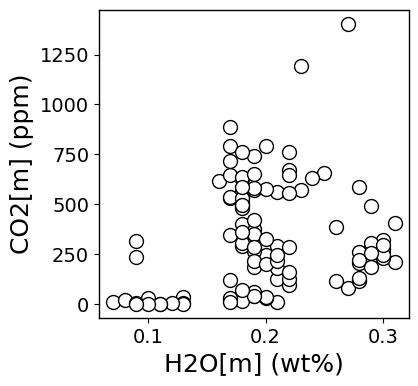

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))

df = MI

ax1.plot(df['H2O (wt%) (wt%, PEC-corr) MI'], df['Total CO2 (PEC-corrected) ppm'], 'ok', mfc='white')

ax1.set_xlabel('H2O[m] (wt%)')
ax1.set_ylabel('CO2[m] (ppm)')

However, the H<sub>2</sub>O contents of the MI have been reset by diffusive requilibration (Wieser et al. 2021). Hence we set the MI H2O contents to 0.5 wt% as in Wieser et al. (2021).

In [5]:
for row in range(0,len(MI),1):
    if MI.loc[row,'type'] == 'MI':
        MI.loc[row,'H2O (wt%) (wt%, PEC-corr) MI'] = 0.5

## Exercise 1: Calculate pressure and fluid composition from melt and fluid inclusion data

In this exercise we will calculate pressures and fluid compositions from MI and FI data from the 2018 Lower East Rift Zone eruption of Kı̄lauea (Wieser et al., 2021; DeVitre & Wieser, 2024) using the tools VESIcal (Iacovino et al., 2021), DiadFit (Wieser & DeVitre, 2024), VolFe (Hughes et al., 2025), and Thermobar (Wieser et al., 2022) through the VICTOR platform (Lev et al., 2025). 

For melt compositions, this is based on the fact that - for a particular major/minor element composition, temperature, and volatile content (partcuarly H<sub>2</sub>O and CO<sub>2</sub>) of the melt - there is a unique pressure at which the melt will be vapor saturated, called the pressure of vapor saturation, and the coexisting fluid will have a unique composition (see Hughes et al., 2024 for more details). This is often applied to MI data to calculate pressures of magma storage or submarine matrix glass (MG) data to estimate eruption pressures, which in both cases can be converted to depths given overburden density. The fluid composition is sometimes used to estimate the composition of MI-hosted bubbles to reconstruct MI compositions at entrapment. 

Alternatively, for fluid compositions, the density of CO<sub>2</sub> in a fluid co-existing with a melt is highly pressure-sensitive. Hence, when combined with an entrapment temperature, the CO<sub>2</sub> density can be converted to pressure using an equation of state for CO<sub>2</sub> (see ??? for more details). This is often applied to FI data to also calculate pressures of magma storage.

### 1.1 Calculate temperature using Thermobar

A temperature is requied to calculate pressures and fluid compositions from MI/MG data. Thermobar has a huge variety of thermometers available to choose from. 

More information on Thermobar can be found at https://thermobar.readthedocs.io/en/latest/

Run the next cell to see the options available in Thermobar just for liquid-only thermometers.

In [ ]:
help(tb.calculate_liq_only_temp)

Following Wieser et al. (2021), we calculate the temperature using the MgO-liquid thermometer of Helz & Thornber (1987) implemented in Thermobar. 

Thermobar requires certain column names to recognise what each column contains - so first we'll need to rename the columns to be compatible with Thermobar. Thermobar also assumes the composition is in wt%, so anything that isn't would need to be converted. Then we can run the calculation and add the results to the original dataframe!

In [6]:
# renames column names to be compatible with Thermobar
MI_tb = MI.rename(columns = {"SiO2 (wt%, PEC-corr) MI":"SiO2_Liq","TiO2 (wt%, PEC-corr) MI":"TiO2_Liq","Al2O3 (wt%, PEC-corr) MI":"Al2O3_Liq","FeO (wt%, PEC-corr) MI":"FeOt_Liq","MnO (wt%, PEC-corr) MI":"MnO_Liq","MgO (wt%, PEC-corr) MI":"MgO_Liq","CaO (wt%, PEC-corr) MI":"CaO_Liq",
                                               "Na2O (wt%, PEC-corr) MI":"Na2O_Liq","K2O (wt%, PEC-corr) MI":"K2O_Liq","P2O5 (wt%, PEC-corr) MI":"P2O5_Liq","H2O (wt%) (wt%, PEC-corr) MI":"H2O_Liq"})

# calculate temperature in celcius (hence -273.15) using MgO-Lq thermometer of Helz & Thornber (1987) using Thermobar
T_C = tb.calculate_liq_only_temp(liq_comps=MI_tb, equationT="T_Helz1987_MgO")-273.15

# adds temperatures to original dataframe
MI.insert(1,"T_C",T_C)

We can plot the MgO content against the temperature to see the correlation.

Text(0, 0.5, 'T (C)')

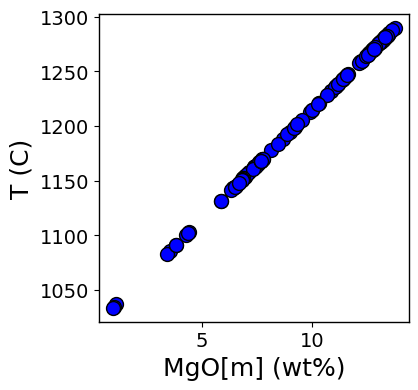

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))

df = MI

ax1.plot(df['MgO (wt%, PEC-corr) MI'], df['T_C'], 'ok', mfc='blue')

ax1.set_xlabel('MgO[m] (wt%)')
ax1.set_ylabel('T (C)')

### 1.2 Calculate pressure and fluid composition 

#### 1.2.1 VESIcal

We can now calculate the pressure of vapor saturation and fluid composition using VESIcal, which assumes the fluid and melt only contain oxidised C-O-H-bearing species (e.g., CO<sub>2</sub> and H<sub>2</sub>O). 

More information on VESIcal can be found at https://vesical.readthedocs.io/en/latest/

There are multiple model options available in VESIcal for the H<sub>2</sub>O and CO<sub>2</sub> solubility, which can be explored changing the 'model' option. Run the cell below to list the models available.

In [ ]:
vc.get_model_names()

Here we'll use Iacono-Marziano et al. (2021) [IaconoMarziano]. <i>??? Can use MagmaSat if it'll be running on VICTOR ??? </i>

Note that how the melt composition is normalised is important for the results and different H<sub>2</sub>O-CO<sub>2</sub> models use different normalisation routines (further explanations can be found in Iacovino et al., 2021, and Wieser et al., 2021). IaconoMarziano uses the 'additionalvolatiles' normalisation routine, whereby the anhydrous melt composition is normalised to 100 wt%; CO<sub>2</sub> and H<sub>2</sub>O are added on top (i.e., the sum is greater than 100 wt%); and then everything is renormalised to 100 wt%.

In [8]:
# chooses model option and normalisation routine
# Iacono-Marziano et al. (2012)
model_vc, normalisation_vc = 'IaconoMarziano', 'additionalvolatiles'

Now we can run VESIcal using our chosen H<sub>2</sub>O-CO<sub>2</sub> model. As with Thermobar, VESIcal requires certain (but different) column headers to understand the input data. This is why we changed the column headers in the notebook rather than in the spreadsheet. Also, CO<sub>2</sub> needs to be in wt% not ppm, so we convert it. Then we use the <i>calculate_equilibrium_fluid_comp</i> function to calculate both pressure and fluid composition.

In [9]:
# renames column names to be compatible with VESIcal
MI_vc = MI.rename(columns = {"SiO2 (wt%, PEC-corr) MI":"SiO2","TiO2 (wt%, PEC-corr) MI":"TiO2","Al2O3 (wt%, PEC-corr) MI":"Al2O3","FeO (wt%, PEC-corr) MI":"FeOt","MnO (wt%, PEC-corr) MI":"MnO","MgO (wt%, PEC-corr) MI":"MgO","CaO (wt%, PEC-corr) MI":"CaO",
                                               "Na2O (wt%, PEC-corr) MI":"Na2O","K2O (wt%, PEC-corr) MI":"K2O","P2O5 (wt%, PEC-corr) MI":"P2O5","H2O (wt%) (wt%, PEC-corr) MI":"H2O"})

# converts CO2 from ppm to wt% and uses header compatible with VESIcal
MI_vc['CO2'] = MI_vc['Total CO2 (PEC-corrected) ppm']/10000.

# runs calculation with model and normalisation routine
MI_vc.to_csv('MI_vc.csv', index=True, header=True)
MI_vc_ = vc.BatchFile('MI_vc.csv')
norm_data = MI_vc_.get_data(normalization=normalisation_vc)
fixed_norm_data = vc.BatchFile(filename=None, dataframe=norm_data)
results_pvsat_vc = fixed_norm_data.calculate_equilibrium_fluid_comp(temperature='T_C',model=model_vc)

c:\Users\erych\miniconda3\envs\volfe_prod\Lib\site-packages\VESIcal\batchfile.py:168: RuntimeWarning: No Label column given, so column 'Unnamed: 0' was chosen for you. To choose your own, set label='<column-name>'.
  data = self.try_set_index(data, label)
C:\Users\erych\AppData\Local\Temp\ipykernel_53384\1202007828.py:10: RuntimeWarning: Total iron column FeOt detected. This column will be treated as FeO. If Fe2O3 data are not given, Fe2O3 will be 0.0. In future, an option to calcualte FeO/Fe2O3 based on fO2 will be implemented.
  MI_vc_ = vc.BatchFile('MI_vc.csv')
c:\Users\erych\miniconda3\envs\volfe_prod\Lib\site-packages\VESIcal\batchfile.py:230: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate o

And we plot to see how the melt volatile content changes with the calculated pressure and what the fluid composition is doing as well!

Text(0.5, 0, 'CO2[f] (mol. frac.)')

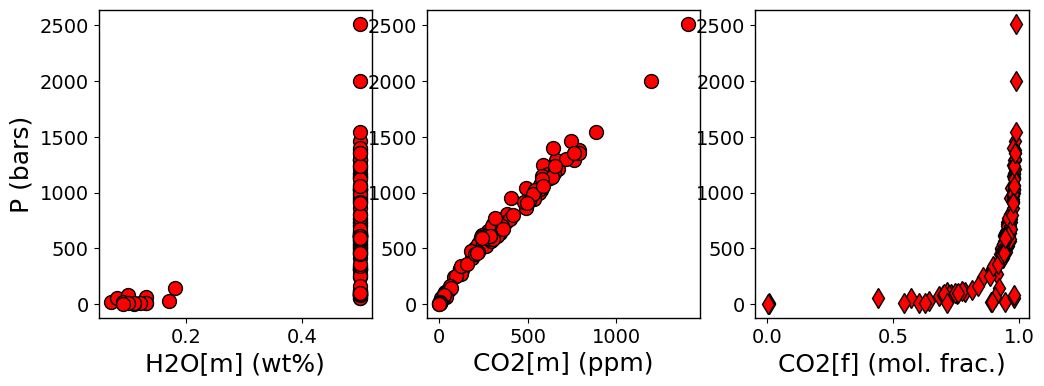

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

df = results_pvsat_vc

ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H2O[m] (wt%)')
ax2.set_xlabel('CO2[m] (ppm)')
ax3.set_xlabel('CO2[f] (mol. frac.)')

#### 1.2.2 VolFe

We can also calculate the pressure of vapor saturation and fluid composition using VolFe, which assumes the fluid and melt contain a variety of reduced and oxidised C-O-H-S-bearing species. This needs additional information, such as some estimate of an oxygen fugacity related variable (e.g., fO2, deltaFMQ, deltaNNO, Fe3+/FeT, or S6+/ST). We'll use a value of deltaFMQ+0.2 for all MI and MG, which is within the range described in Wieser et al. (2021), but in other examples this can be specified for each composition individually.

More information on VolFe can be found at https://volfe.readthedocs.io/en/latest/

There are lots of different options available in VolFe. Similar to VESIcal, there are different H2O and CO2 solubility models, but there are also different sulfide and sulfate solubility models and relationships between Fe3+/FeT and fO2 to choose from. Run the cell below to see all the parameters that can be changed in VolFe.

In [ ]:
help(vf.make_df_and_add_model_defaults)

Here we'll focus on the H2O, CO2, sulfide, and sulfate solubility options:

In [ ]:
# H2O solubility model
help(vf.C_H2O)

In [ ]:
# CO2 solubility model
help(vf.C_CO3)

In [ ]:
# sulfide solubility model
help(vf.C_S)

In [ ]:
# sulfate solubility model
help(vf.C_SO4)

We'll choose to use water solubility model from Fig. S2 of Hughes et al. (2024); CO2 solubility model from eq. (7) from Dixon (1997); sulfide solubility model from eq. (10.34) of O'Neill (2021); and sulfate solubility model from eq. (12a) of O'Neill & Mavrogenes (2022) - everything else will use the default options in VolFe. All options used are outputted in the results.

In [11]:
# choose the options I want - everything else will use the default options
models_vf = [['water','Basalt_Hughes24'],['carbon dioxide','Basalt_Dixon97'],['sulfide','ONeill21dil'],['sulfate','ONeill22dil']]

# turn to dataframe with correct column headers and indexes    
models_vf = vf.make_df_and_add_model_defaults(models_vf)

VolFe also uses different column names...

In [12]:
MI_vf = MI.rename(columns = {'Sample Name':'Sample',"SiO2 (wt%, PEC-corr) MI":"SiO2","TiO2 (wt%, PEC-corr) MI":"TiO2","Al2O3 (wt%, PEC-corr) MI":"Al2O3","FeO (wt%, PEC-corr) MI":"FeOT","MnO (wt%, PEC-corr) MI":"MnO","MgO (wt%, PEC-corr) MI":"MgO","CaO (wt%, PEC-corr) MI":"CaO",
                                               "Na2O (wt%, PEC-corr) MI":"Na2O","K2O (wt%, PEC-corr) MI":"K2O","P2O5 (wt%, PEC-corr) MI":"P2O5","H2O (wt%) (wt%, PEC-corr) MI":"H2O", "Total CO2 (PEC-corrected) ppm":'CO2ppm',"S_MI_PEC EPMA":"STppm"})

And add DFMQ to each row...

In [13]:
# Adds oxygen fugacity constraint to each row in the dataframe
MI_vf['DFMQ'] = 0.20

And then we run the calculations...

In [14]:
# runs the calculation
results_pvsat_vf = vf.calc_Pvsat(MI_vf, models= models_vf)

... and compare them to the VESIcal results:

Text(0.5, 0, 'SO2/CO2[f] (mole frac.)')

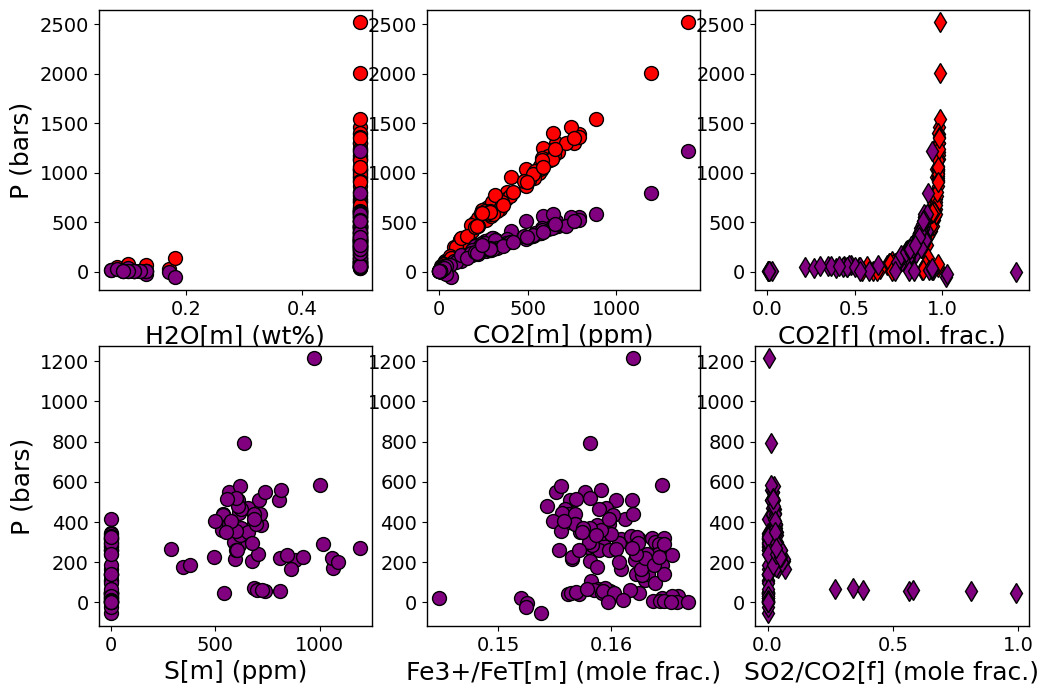

In [ ]:
fig, ((ax1, ax2, ax3),(ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12,8))

df = results_pvsat_vc
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

df = results_pvsat_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], 'ok', mfc='purple')
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], 'ok', mfc='purple')
ax3.plot(df['xgCO2_mf'], df['P_bar'], 'dk', mfc='purple')
ax4.plot(df['ST_ppmw'], df['P_bar'], 'ok', mfc='purple')
ax5.plot(df['Fe3+/FeT'], df['P_bar'], 'ok', mfc='purple')
ax6.plot(df['xgSO2_mf']/df['xgCO2_mf'], df['P_bar'], 'dk', mfc='purple')

ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H2O[m] (wt%)')
ax2.set_xlabel('CO2[m] (ppm)')
ax3.set_xlabel('CO2[f] (mol. frac.)')
ax4.set_ylabel('P (bars)')
ax4.set_xlabel('S[m] (ppm)')
ax5.set_xlabel('Fe3+/FeT[m] (mole frac.)')
ax6.set_xlabel('SO2/CO2[f] (mole frac.)')

What?! Negative pressures?! CO<sub>2</sub> vapor compositions more than 1?!

These are for MG with ~65 wt% SiO<sub>2</sub>, where the eq. (7) from Dixon (1997) parameterisation is not appropriate for and actually ends up predicting a negative solubility function... we'll remove those composition for further comparisons! But it's important to check where the calibrations are appropriate!

In [16]:
results_pvsat_vf = results_pvsat_vf[results_pvsat_vf['SiO2_wtpc'] < 60.]

### ??? 1.3 FLUID INCLUSION PART ???

## Exercise 2: Calculate degassing paths

In this exercise we will calculate degassing paths applicable to the 2018 Lower East Rift Zone eruption of Kı̄lauea and compare it to melt and fluid inclusion data (Wieser et al., 2021; DeVitre & Wieser, 2024) using the tools VESIcal (Iacovino et al., 2021), VolFe (Hughes et al., 2025), and Sulfur_X (Ding et al., 2023) through the VICTOR platform (Lev et al., 2025).

### 2.1 Initial melt composition

We choose the MI with the highest CO2 content as the starting point for the degassing calcuations

In [ ]:
# row number with highest CO2 content
row = MI['Total CO2 (PEC-corrected) ppm'].idxmax()

We also specify the initial fO2 (DFMQ = 0.2 as before) and H2O = 0.5 wt%

In [ ]:
DFMQ = 0.2
H2Oi = 0.5 # wt%

And combine this all into a single dictionary to use

In [19]:
ini_comp = {'SiO2':  float(MI.loc[row,'SiO2 (wt%, PEC-corr) MI']),
 'TiO2':   float(MI.loc[row,'TiO2 (wt%, PEC-corr) MI']),
 'Al2O3': float(MI.loc[row,'Al2O3 (wt%, PEC-corr) MI']),
 'Fe2O3':  0.,
 'Cr2O3':  0.0,
 'FeO':    float(MI.loc[row,'FeO (wt%, PEC-corr) MI']),
 'MnO':    float(MI.loc[row,'MnO (wt%, PEC-corr) MI']),
 'MgO':    float(MI.loc[row,'MgO (wt%, PEC-corr) MI']),
 'NiO':    0.0,
 'CoO':    0.0,
 'CaO':    float(MI.loc[row,'CaO (wt%, PEC-corr) MI']),
 'Na2O':   float(MI.loc[row,'Na2O (wt%, PEC-corr) MI']),
 'K2O':    float(MI.loc[row,'K2O (wt%, PEC-corr) MI']),
 'P2O5':   float(MI.loc[row,'P2O5 (wt%, PEC-corr) MI']),
 'H2O':    H2Oi,
 'CO2':    float(MI.loc[row,'Total CO2 (PEC-corrected) ppm'])}

### 2.2 Calculate degassing path

Now we'll calculate degassing paths using various tools. In all our calculations we will assume closed-system degassing, but open-system degassing calculations are possible with all these tools. Additionally we'll assume isothermal (i.e., single temperature), no crystallisation, and that there is only melt at the beginning of the degassing path (i.e., no additional vapor).

#### 2.2.1 VESIcal

For consistency, we'll use the same model options as before, but these can be changed!

In [ ]:
# define initial melt composition
sample_vc = vc.Sample({'SiO2':  ini_comp['SiO2'],
 'TiO2':   ini_comp['TiO2'],
 'Al2O3': ini_comp['Al2O3'],
 'Fe2O3':  ini_comp['Fe2O3'],
 'Cr2O3':  ini_comp['Cr2O3'],
 'FeO':    ini_comp['FeO'],
 'MnO':    ini_comp['MnO'],
 'MgO':    ini_comp['MgO'],
 'NiO':    ini_comp['NiO'],
 'CoO':    ini_comp['CoO'],
 'CaO':    ini_comp['CaO'],
 'Na2O':   ini_comp['Na2O'],
 'K2O':    ini_comp['K2O'],
 'P2O5':   ini_comp['P2O5'],
 'H2O':    ini_comp['H2O'],
 'CO2':    ini_comp['CO2']/10000.}) # CO2 must be in wt%

In [ ]:
# run calculation
# temperature is specified in the function
results_degas_vc = vc.calculate_degassing_path(sample=sample_vc,temperature=float(MI.loc[row,'T_C']),model=model_vc).result

#### 2.2.2 VolFe

VolFe requires additional inputs to VESIcal (e.g., S and fO2). Again, we'll use the same model options as before, but these can be changed if required.

In [ ]:
# Define initial melt composition

sample_vf_ = {'Sample':MI.loc[row,'Sample Name'],
           'T_C': float(MI.loc[row,'T_C']), # Temperature in 'C
           'SiO2': ini_comp['SiO2'], # wt%
           'TiO2': ini_comp['TiO2'], # wt%
           'Al2O3': ini_comp['Al2O3'], # wt%
           'FeOT': ini_comp['FeO'], # wt%
           'MnO': ini_comp['MnO'], # wt%
           'MgO': ini_comp['MgO'], # wt%
           'CaO': ini_comp['CaO'], # wt%
           'Na2O': ini_comp['Na2O'], # wt%
           'K2O': ini_comp['K2O'], # wt%
           'P2O5': ini_comp['P2O5'], # wt%
           'H2O': ini_comp['H2O'], # wt%
           'CO2ppm': ini_comp['CO2'], # ppm
           'STppm': float(MI.loc[row,'S_MI_PEC EPMA']), # ppm
           'DFMQ': DFMQ}

sample_vf = pd.DataFrame(sample_vf_, index=[0])

In [ ]:
# run calculation
results_degas_vf = vf.calc_gassing(sample_vf, models = models_vf)

  0%|          | 0.0/1215 [00:00<?, ?it/s]

1200.0 : Switching solve species from O2-CO-S2 to O2-CO-H2 (first time)


  8%|▊         | 100.0/1215 [00:00<00:03, 298.43it/s]

1100.0 : Switching solve species from O2-CO-H2 to O2-H2-S2 (first time)
1000.0 : Switching solve species from O2-CO-S2 to O2-CO-H2 (first time)


 16%|█▋        | 200.0/1215 [00:01<00:03, 308.59it/s]

...

 66%|██████▌   | 800.0/1215 [00:04<00:02, 158.34it/s]

300.0 : Switching solve species from O2-CO-H2 to O2-H2-S2 (first time)


 74%|███████▍  | 900.0/1215 [00:05<00:02, 157.19it/s]

200.0 : Switching solve species from O2-CO-S2 to O2-CO-H2 (first time)


 99%|█████████▊| 1199.0/1215 [00:18<00:00, 63.69it/s] 


#### 2.2.3 Sulfur_X

We can also run degassing calculations with Sulfur_X, which like VolFe includes S.

More information on VolFe can be found at https://github.com/sdecho/Sulfur_X


First we have to define the directory where Sulfur_X is hosted

In [24]:
SulfurX_directory = 'Sulfur_X-main/'

Next we define the initial melt composition. We won't use it today, but the sulfide composition can be defined as well as the sulfur isotope ratio (these can also be used in VolFe). If crystallisation is required, this should also be defined.

In [ ]:
# Temperature in C
temperature = float(MI.loc[row,'T_C'])

# fO2 relative to FMQ buffer
delta_FMQ = DFMQ

# initial H2O in wt.%
H2O_initial = ini_comp['H2O']

# initial CO2 in ppm
CO2_initial = ini_comp['CO2']

# initial sulfur in ppm
S_initial = float(MI.loc[row,'S_MI_PEC EPMA'])

# melt composition
sio2 = float(ini_comp['SiO2'])
al2o3 = float(ini_comp['Al2O3'])
feot = float(ini_comp['FeO'])
mgo = float(ini_comp['MgO'])
cao = float(ini_comp['CaO'])
na2o = float(ini_comp['Na2O'])
k2o = float(ini_comp['K2O'])
p2o5 = float(ini_comp['P2O5'])
mno = float(ini_comp['MnO'])
tio2 = float(ini_comp['TiO2'])

# Sulfide composition in wt%, only relevant if SCSS is of interest
sulfide = {"Fe": 65.43,
            "Ni": 0,
            "Cu": 0,
            "O": 0,
            "S": 36.47
            }

# initial sulfur isotope ratio
d34s_m_initial = 1

# if crystallization is enabled, H2O-melt fraction relation is specified using H2O-K2O relation (K2O = a * H2O +b),
# assuming K2O is perfectly incompatible. The given a and b are based on H2O-K2O relation for Fuego magma from
# Lloyd et al. (2013). Both H2O and K2O are in wt.%. If crystallization is disabled, or running on magmas similar to Fuego,
# leave them unchanged.
slope_h2o = -0.713
constant_h2o = 3.689

These parameters effect how the calculation is performed.

In [ ]:
# The total steps of pressure from initial P to 1 bar.
l = 1000

# Total number of runs along degassing
m = 1000

# ???
INC = 20

# ???
BAR = 0

# Tolerance (sigma) of log_10(fO2)
sigma = .005

This allows you to pick different model options. Here we'll use the CO2-H2O solubility of Iacono-Marziano et al. (2012) to match the VESIcal calculations and the S speciation model of O'Neil & Mavrogenes (2022) to match the VolFe calculations. Crystallisation and sulfide precipitation are turned off and the calculations are closed-system degassing. We do not perform Monte Carlo simulations.

In [ ]:
# Which COH degassing model to use? 1 for VolatileCalc; 0 for Iacono_Marziano model
COH_model = 0

# Which S speciation model to use? 0 for Nash model; 1 for O'Neill and Mavrogenes (2022) model; 100 for Muth model
S_Fe_choice = 1

# Changing fO2 or not? If 1, fO2 changes by S degassing and S-Fe electron exchange;
# if 0, fO2 if buffered at the delta_FMQ
fo2_tracker = 1

# Enable crystallization (yes=1,no=0)
crystallize = 0

# sulifde saturation: if 0, no sulfide precipitation; if 1, sulfide precipitation enabled
sulfide_pre = 0

# Use monte carlo simulation for error estimate? (1/0)
# If 1, input number of runs, otherwise ignore
monte_carlo = 0
mc_runs = 0

# Decimal value between 0 and 1, percentage of melt
melt_fraction = 1

# degassing style: if 0, fully closed degassing; if x, degassing become open when pressure is lower than xMPa
open_degassing = 0

These final options are about where the data are saved to and where MI data are taken to for plotting.

In [28]:
#Melt inclusion data file (.csv)
mi_name = SulfurX_directory+"Fuego.csv"

# Output path
output_path = SulfurX_directory+'results_folder'

#Save plot images? (True/False)
save_img = False

Finally, we input all these values into the .py files to run the calculation.

In [ ]:
f = open(SulfurX_directory+"main_Fuego.py","r+")
main = f.readlines()
main[32] = f"""temperature = {temperature}\n"""
main[35] = f"""delta_FMQ = {delta_FMQ}\n"""
main[37] = f"""H2O_initial = {H2O_initial}\n"""
main[39] = f"""CO2_initial = {CO2_initial}\n"""
main[41] = f"""S_initial = {S_initial}\n"""
main[43] = f"""d34s_m_initial = {d34s_m_initial}\n"""
main[45] = f"""choice = {crystallize}\n"""
main[47] = f"""COH_model = {COH_model}\n"""
main[50] = f"""fo2_tracker = {fo2_tracker}\n"""
main[54] = f"""monte_carlo = {monte_carlo}\n"""
main[57] = f"""    m_run = {mc_runs}\n"""
main[63] = f"""l = {l}\n"""
main[65] = f"""m = {m}\n"""
main[68] = f"""sulfide = {{"Fe": {sulfide["Fe"]},\n"""
main[69] = f"""         "Ni": {sulfide["Ni"]},\n"""
main[70] = f"""         "Cu": {sulfide["Cu"]},\n"""
main[71] = f"""         "O": {sulfide["O"]},\n"""
main[72] = f"""         "S": {sulfide["S"]},\n"""
main[75] = f"""open_degassing = {open_degassing}\n"""
main[77] = f"""sulfide_pre = {sulfide_pre}\n"""
main[85] = f"""S_Fe_choice = {S_Fe_choice}\n"""
main[88] = f"""sigma = {sigma}\n"""
main[94] = f"""slope_h2o = {slope_h2o}\n"""
main[95] = f"""constant_h2o = {constant_h2o}\n"""
main[102] = f"""mi_name = '{mi_name}'\n"""
main[107] = f"""folder = Path("{output_path}")\n"""
f.seek(0)
f.writelines(main)
f.truncate()
f.close()

g = open(SulfurX_directory+"degassingrun.py","r+")
degas = g.readlines()
degas[13] = f"""INC = {INC}\n"""
degas[14] = f"""BAR = {BAR}\n"""
degas[35] = f"""        self.sulfide = {{"Fe": {sulfide["Fe"]},\n"""
degas[36] = f"""                        "Ni": {sulfide["Ni"]},\n"""
degas[37] = f"""                        "Cu": {sulfide["Cu"]},\n"""
degas[38] = f"""                        "O": {sulfide["O"]},\n"""
degas[39] = f"""                        "S": {sulfide["S"]},\n"""
g.seek(0)
g.writelines(degas)
g.truncate()
g.close()

g = open(SulfurX_directory+"melt_composition.py","r+")
melt_comp = g.readlines()
melt_comp[76] = f"""            sio2 = {sio2} / melt_fraction\n"""
melt_comp[77] = f"""            al2o3 = {al2o3} / melt_fraction\n"""
melt_comp[78] = f"""            feot = {feot} / melt_fraction\n"""
melt_comp[79] = f"""            mgo = {mgo} / melt_fraction\n"""
melt_comp[80] = f"""            cao = {cao} / melt_fraction\n"""
melt_comp[81] = f"""            na2o = {na2o} / melt_fraction\n"""
melt_comp[82] = f"""            k2o = {k2o} / melt_fraction\n"""
melt_comp[83] = f"""            p2o5 = {p2o5} / melt_fraction\n"""
melt_comp[84] = f"""            mno = {mno} / melt_fraction\n"""
melt_comp[85] = f"""            tio2 = {tio2} / melt_fraction\n"""
g.seek(0)
g.writelines(melt_comp)
g.truncate()
g.close()

And run the calculation! Make sure the path is correct here and it will ask you to confirm the starting conditions are reasonable to continue the calculation - if you don't do anything at this point, the calculation won't run!

In [30]:
%run Sulfur_X-main/main_Fuego.py

 The initial vapor saturation pressure is 4000.0 bar, and the initial vapor concentration is XH2O = 0.9 and XCO2 = 0.09999999999999998.
The initial Ferric iron ratio is 0.15995225760164797
The initial sulfate ratio in the melt is 0.0450891481805995
Continuing with Sulfur_X


PermissionError: [Errno 13] Permission denied: 'Sulfur_X-main\\results_folder\\test_Fuego_closedT1169.775_dFMQ0.2_H2O0.5_CO21405.0_fO2track.csv'

In [ ]:
# load results from where they are saved
results_degas_sx = pd.read_csv('Sulfur_X-main/results_folder/test_Fuego_closedT'+str(temperature)+'_dFMQ'+str(delta_FMQ)+'_H2O'+str(H2O_initial)+'_CO2'+str(CO2_initial)+'_fO2track.csv')

### Plot and compare to data

We can now plot the different degassing calculations and compare the MI and FI data!

Text(0.5, 0, 'SO2/CO2[f] (mole frac.)')

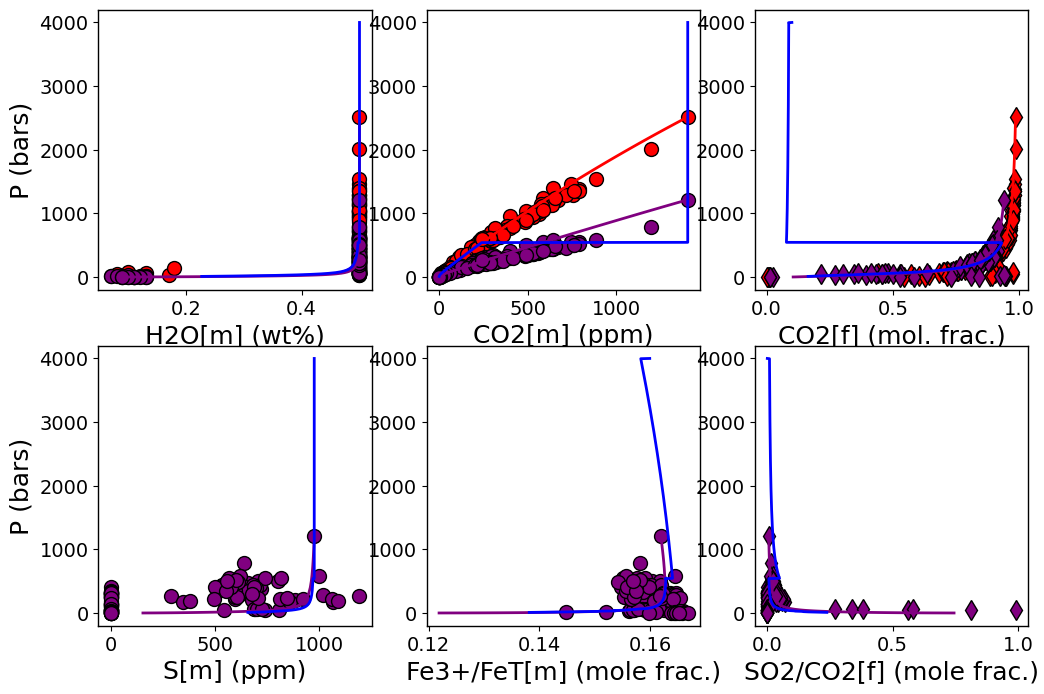

In [32]:
fig, ((ax1, ax2, ax3),(ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12,8))

df = results_pvsat_vc
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

df = results_degas_vc
ax1.plot(df['H2O_liq'], df['Pressure_bars'], '-', color='red', linewidth=2)
ax2.plot(df['CO2_liq']*10000, df['Pressure_bars'], '-', color='red', linewidth=2)
ax3.plot(df['CO2_fl'], df['Pressure_bars'], '-', color='red', linewidth=2)

df = results_pvsat_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], 'ok', mfc='purple')
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], 'ok', mfc='purple')
ax3.plot(df['xgCO2_mf'], df['P_bar'], 'dk', mfc='purple')
ax4.plot(df['ST_ppmw'], df['P_bar'], 'ok', mfc='purple')
ax5.plot(df['Fe3+/FeT'], df['P_bar'], 'ok', mfc='purple')
ax6.plot(df['xgSO2_mf']/df['xgCO2_mf'], df['P_bar'], 'dk', mfc='purple')

df = results_degas_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], '-', color='purple', linewidth=2)
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], '-', color='purple', linewidth=2)
ax3.plot(df['xgCO2_mf'], df['P_bar'], '-', color='purple', linewidth=2)
ax4.plot(df['ST_ppmw'], df['P_bar'], '-', color='purple', linewidth=2)
ax5.plot(df['Fe3+/FeT'], df['P_bar'], '-', color='purple', linewidth=2)
ax6.plot(df['xgSO2_mf']/df['xgCO2_mf'], df['P_bar'], '-', color='purple', linewidth=2)

df = results_degas_sx
ax1.plot(df['wH2O_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax2.plot(df['wCO2_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax3.plot(df['XCO2_fluid'], df['pressure']*10., '-', color='blue', linewidth=2)
ax4.plot(df['wS_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax5.plot(df['ferric_ratio'], df['pressure']*10., '-', color='blue', linewidth=2)
ax6.plot(df['XSO2_fluid']/df['XCO2_fluid'], df['pressure']*10., '-', color='blue', linewidth=2)

ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H2O[m] (wt%)')
ax2.set_xlabel('CO2[m] (ppm)')
ax3.set_xlabel('CO2[f] (mol. frac.)')
ax4.set_ylabel('P (bars)')
ax4.set_xlabel('S[m] (ppm)')
ax5.set_xlabel('Fe3+/FeT[m] (mole frac.)')
ax6.set_xlabel('SO2/CO2[f] (mole frac.)')

## 3 Describing and citing calculations

Here is an example of how you might describe and cite the calculations presented here - including this notebook in Supplementary Material would ensure the calculations are reproduceable!

<i>All calculations were performed using the VICTOR platform (Lev et al., 2025). Melt inclusion data is from Wieser et al. (2021) and the fluid inclusion data from DiVitre & Wieser (2024). Temperature was calculated using the MgO-liquid thermometer from Helz & Thornber (1987) implemented in Thermobar (v1.0.60; Wieser et al., 2022). Pressure and fluid composition for melt inclusions were calculated using the model of Iacono-Marziano et al. (2012) implemented in VESIcal (v1.2.10) and models shown in Table 1 implemented in VolFe (v1.0.2; Hughes et al., 2025). SOMETHING FOR FI.</i>

Table 1. Model options used in VolFe calculations.
| Model dependent variable | Reference |
|---|---|
| O2 fugacity coefficient | Shi and Saxena (1992) |
| CO fugacity coefficient | Shi and Saxena (1992) |
| H2 fugacity coefficient | Shaw and Wones (1964) |
| S2 fugacity coefficient | Shi and Saxena (1992) |
| CO2 fugacity coefficient | Shi and Saxena (1992) |
| H2O fugacity coefficient | Eq. (4, 6: T > 673 K, A1, A2, A3) and Table 1 in Holland and Powell (1991) | 
| SO2 fugacity coefficient | Shi and Saxena (1992) as modified in Fig. S1 of Hughes et al. (2022) |
| CH4 fugacity coefficient | Shi and Saxena (1992) |
| H2S fugacity coefficient | Shi and Saxena (1992) as modified in Fig. S1 of Hughes et al. (2024) |
| OCS fugacity coefficient | Shi and Saxena (1992) |
| CO2 equilibrium constant | Reaction (c) in Table 1 of Ohmoto and Kerrick (1977) |
| H2O equilibrium constant | Reaction (d) in Table 1 of Ohmoto and Kerrick (1977) |
| SO2 equilibrium constant | Reaction (f) in Table 1 of Ohmoto and Kerrick (1977) |
| CH4 equilibrium constant | Reaction (e) in Table 1 of Ohmoto and Kerrick (1977) |
| H2S equilibrium constant | Reaction (h) in Table 1 of Ohmoto and Kerrick (1977) |
| OCS equilibrium constant | Eq. (8) in Moussallam et al. (2019) |
| H2OT solubility function | Fig. S2 in Hughes et al. (2024) |
| CO2,T solubility function | Eq. (7) in Dixon (1997) |
| H2,mol solubility function | Table S4 in Hughes et al. (2024) |
| COmol solubility function | Table S4 in Hughes et al. (2024) |
| CH4,mol solubility function | Eq. (7a) from Ardia et al. (2013) |
| *S2- solubility function | Eq. (10.43) from O’Neill (2021) (including the effect of H2O dilution) |
| SO42- solubility function | Eq. (12a) from O’Neill and Mavrogenes (2022) (including the effect of H2O dilution) |
| H2Smol solubility function | Fig. S6 in Hughes et al. (2024) |
| CO2,T equilibrium constant | All CO32- as basalt |
| Fe3+/FeT | Eq. (A-5, 6) from Kress and Carmichael (1991) |
| FMQ buffer | Frost (1991) |


### 3.1 References

(e.g., Solwcad - Papale et al. 2006; D-Compress - Burgisser et al. 2015; CHOSETTO - Moretti and Ottonello 2003, Moretti and Papale 2004; EVo - Liggins et al. 2020, 2022; MAGEC - Sun and Lee 2022, Sun and Yao 2024)

Ardia, P., Hirschmann, M.M., Withers, A.C. and Stanley, B.D., 2013. Solubility of CH4 in a synthetic basaltic melt, with applications to atmosphere–magma ocean–core partitioning of volatiles and to the evolution of the Martian atmosphere. Geochimica et Cosmochimica Acta, 114, pp.52-71. https://doi.org/10.1016/j.gca.2013.03.028

DeVitre, C.L. and Wieser, P.E., 2024. Reliability of Raman analyses of CO2-rich fluid inclusions as a geobarometer at Kīlauea. Geochemical perspectives letters, 29. https://doi.org/10.7185/geochemlet.2404

Ding et al., 2023

Dixon, J.E., 1997. Degassing of alkalic basalts. American Mineralogist, 82(3-4), pp.368-378. https://doi.org/10.2138/am-1997-3-415

Frost, B. R. (1991). “Introduction to oxygen fugacity and its petrologic importance”. Oxide minerals: Petrologic and Magnetic Significance. Edited by D. H. Lindsley. Volume 25. De Gruyter, pages 1–10.

Helz, R.T. and Thornber, C.R., 1987. Geothermometry of Kilauea Iki lava lake, Hawaii. Bulletin of volcanology, 49(5), pp.651-668. https://doi.org/10.1007/BF01080357

Holland, T. and R. Powell (1991). “A Compensated-Redlich-Kwong (CORK) equation for volumes and fugacities of CO2 and H2O in the range 1 bar to 50 kbar and 100–1600 °C”. Contributions to Mineralogy and Petrology 109(2), pages 265–273. https://doi.org/10.1007/bf00306484

Hughes, E. C., L. M. Saper, P. Liggins, H. S. C. O’Neill, and E. M. Stolper (2023b). “The sulfur solubility minimum and maximum in silicate melt”. Journal of the Geological Society 180(3). https://doi.org/10.1144/jgs2021-125

Hughes, E. C., P. Liggins, L. Saper, and E. M. Stolper (2024). “The effects of oxygen fugacity and sulfur on the pressure of vapor-saturation of magma”. American Mineralogist 109(3), pages 422–438. https://doi.org/10.2138/am-2022-8739

Hughes, E.C., Liggins, P., Wieser, P. and Stolper, E.M., 2024. VolFe: an open-source Python package for calculating melt-vapor equilibria including silicate melt, carbon, hydrogen, sulfur, and noble gases. Volcanica, 8(2), pp. 457-481. https://doi.org/10.30909/vol/imvc1781

Iacono-Marziano, G., Y. Morizet, E. Le Trong, and F. Gaillard (2012). “New experimental data and semi-empirical parameterization of H2O–CO2 solubility in mafic melts”. Geochimica et Cosmochimica Acta 97, pages 1–23. https://doi.org/10.1016/j.gca.2012.08.035

Iacovino, K., Matthews, S., Wieser, P.E., Moore, G.M. and Bégué, F., 2021. VESIcal Part I: An open‐source thermodynamic model engine for mixed volatile (H2O‐CO2) solubility in silicate melts. Earth and Space Science, 8(11), p.e2020EA001584. https://doi.org/10.1029/2020EA001584

Kress, V. C. and I. S. E. Carmichael (1991). “The compressibility of silicate liquids containing Fe2O3 and the effect of composition, temperature, oxygen fugacity and pressure on their redox states”. Contributions to Mineralogy and Petrology 108(1–2), pages 82–92. https://doi.org/10.1007/bf00307328

Lev, E., Krasnoff, S., Charbonnier, S., Connor, C., Patra, A. and Mullins, A., 2025. VICTOR—A new cyberinfrastructure for volcanology. Volcanica, 8(2), pp.563-582. https://doi.org/10.30909/vol/ikoj4933

Moussallam, Y., C. Oppenheimer, and B. Scaillet (2019). “On the relationship between oxidation state and temperature of volcanic gas emissions”. Earth and Planetary Science Letters 520, pages 260–267. https://doi.org/10.1016/j.epsl.2019.05.036

Ohmoto, H. and D. M. Kerrick (1977). “Devolatilization equilibria in graphitic systems”. American Journal of Science 277(8), pages 1013–1044. https://doi.org/10.2475/ajs.277.8.1013.

O’Neill, H. S. C. (2021). “The Thermodynamic Controls on Sulfide Saturation in Silicate Melts with Application to Ocean Floor Basalts”. Magma Redox Geochemistry, pages 177–213. https://doi.org/10.1002/9781119473206.ch10

O’Neill, H. S. C. and J. A. Mavrogenes (2022). “The sulfate capacities of silicate melts”. Geochimica et Cosmochimica Acta 334, pages 368–382. https://doi.org/10.1016/j.gca.2022.06.020

Shaw, H. R. and D. R. Wones (1964). “Fugacity coefficients for hydrogen gas between O degrees and 1000 degrees C, for pressures to 3000 atm”. American Journal of Science 262(7), pages 918–929. https://doi.org/10.2475/ajs.262.7.918

Shi, P. and S. Saxena (1992). “Thermodynamic modeing of the CHOS fluid system”. American Mineralogist 77(9-10), pages 1038–1049

Wieser, P.E., Lamadrid, H., Maclennan, J., Edmonds, M., Matthews, S., Iacovino, K., Jenner, F.E., Gansecki, C., Trusdell, F., Lee, R.L. and Ilyinskaya, E., 2021. Reconstructing magma storage depths for the 2018 Kı̄lauean eruption from melt inclusion CO2 contents: the importance of vapor bubbles. Geochemistry, Geophysics, Geosystems, 22(2), p.e2020GC009364. https://doi.org/10.1029/2020GC009364

Wieser, P. E., K. Iacovino, S. Matthews, G. Moore, and C. M. Allison (2022a). “VESIcal: 2. A Critical Approach to Volatile Solubility Modeling Using an Open-Source Python3 Engine”. Earth and Space Science 9(2). https://doi.org/10.1029/2021ea001932

Wieser, P., Petrelli, M., Lubbers, J., Wieser, E., Ozaydin, S., Kent, A. and Till, C. (2022) “Thermobar: An open-source Python3 tool for thermobarometry and hygrometry”, Volcanica, 5(2), pp. 349–384. https://doi.org/10.30909/vol.05.02.349384

Wieser, P.E. and DeVitre, C., 2024. DiadFit: an open-source Python3 tool for peak fitting of Raman data from silicate melts and CO2 fluids. Volcanica, 7(1), pp.335-359. https://doi.org/10.30909/vol.07.01.335359 